In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os
import nested_pandas as npd
import pyarrow as pa
from progressbar import progressbar
import pyarrow.parquet as pq
import pyarrow.compute as pc

from astropy.coordinates import SkyCoord
import astropy.units as u
import glob

## Separate only fields in common with feature analysis

In [2]:
used_fields = ['436', '512', '594', '641', '686', '705', '727', '770', '778', '805', 
               '252', '401', '468', '626', '673', '718', '759', '795', '797', '848']

In [3]:
dirname = ['/media/snad/ztf_features/dr24-features_astra-clr_pretrained/embed_no_lc/' + \
          'ztfdr24_astra_embeddings/dataset/Norder=' +  str(i) +'/' for i in range(4, 8) ]

In [4]:
k = 3
flist = os.listdir(dirname[k])
flist_ = [os.listdir(dirname[k] + '/' + flist[j]) for j in range(len(flist))]

In [5]:
# this cell check if the first 3 digits of koid coincide with the fields being scrutinized with features
data_list = []

for i in progressbar(range(len(flist))):
    for j in range(len(flist_[i])):
        data_temp = pd.read_parquet(dirname[k] + flist[i] + '/' + flist_[i][j])
        mask = data_temp['koid'].apply(lambda x: str(x)[:3] in used_fields)

        if sum(mask) > 0:
            data_list.append(data_temp[mask])

100% (4 of 4) |##########################| Elapsed Time: 0:03:31 Time:  0:03:310:44


In [6]:
data_field = pd.concat(data_list, ignore_index=True)

In [7]:
data_field.shape

(480342, 6)

In [9]:
data_field.to_parquet('data/fields_Norder7.parquet')

## Join all the common objects in the same file

In [2]:
flist = glob.glob('data/fields_Norder*.parquet')

In [3]:
data_list = []
for fname in flist:
    table = pq.read_table(fname)
    
    target_type = pa.list_(pa.float32())
    for col in ["embedding_beggining", "embedding_middle", "embedding_end"]:
        table = table.set_column(table.schema.get_field_index(col), col,
                                  pc.cast(table[col], target_type))
    data_temp = table.to_pandas()

    data_list.append(data_temp)
data_fields = pd.concat(data_list, ignore_index=True)

### Average over embeddings

In [4]:
def embed_to_numpy(df, col_name, NDIM=512):
    pa_array = pa.array(df[col_name])
    np_1d_array = pa_array.values.to_numpy(zero_copy_only=False)
    np_2d_array = np_1d_array.reshape(-1, NDIM)
    return np_2d_array

In [5]:
emb_beg = embed_to_numpy(data_fields, "embedding_beggining")
emb_mid = embed_to_numpy(data_fields, "embedding_middle")
emb_end = embed_to_numpy(data_fields, "embedding_end")
emb_avg = 1./3. * (emb_beg + emb_mid + emb_end)


In [6]:
data_fields['embedding_average'] = list(emb_avg)

In [9]:
data_fields.to_parquet('data/embeddings_common_fields.parquet')

## Use only extragalactic fields

In [22]:
data_fields = pd.read_parquet('data/embeddings_common_fields.parquet')

In [11]:
data_fields.shape

(2123149, 7)

In [12]:
galactic_fields = ['436', '512', '594', '641', '686', '705', '727', '770', '778', '805']
extrag_fields = ['252', '401', '468', '626', '673', '718', '759', '795', '797', '848']

In [13]:
mask_extra = data_fields['koid'].apply(lambda x: str(x)[:3] in extrag_fields)

In [14]:
sum(mask_extra)

915727

In [17]:
data_galactic = data_fields[~mask_extra]
data_galactic.to_parquet('/media/snad/ztf_features/dr24-features_astra-clr_pretrained/embed_no_lc/embeddings_galactic_fields.parquet')

In [18]:
data_extrag = data_fields[mask_extra]
data_extrag.to_parquet('/media/snad/ztf_features/dr24-features_astra-clr_pretrained/embed_no_lc/embeddings_extragalactic_fields.parquet')

IOStream.flush timed out


# Isolation Forest

In [47]:
from coniferest.isoforest import IsolationForest
import matplotlib.pylab as plt

In [2]:
data = pd.read_parquet('/media/snad/ztf_features/dr24-features_astra-clr_pretrained/embed_no_lc/embeddings_extragalactic_fields.parquet')

In [35]:
data_use = data['embedding_average']

In [44]:
data_input = np.array([data_use.iloc[i] for i in range(data_use.shape[0])])

In [46]:
model = IsolationForest(random_seed=42)
model.fit(data_input)
scores = model.score_samples(data_input)

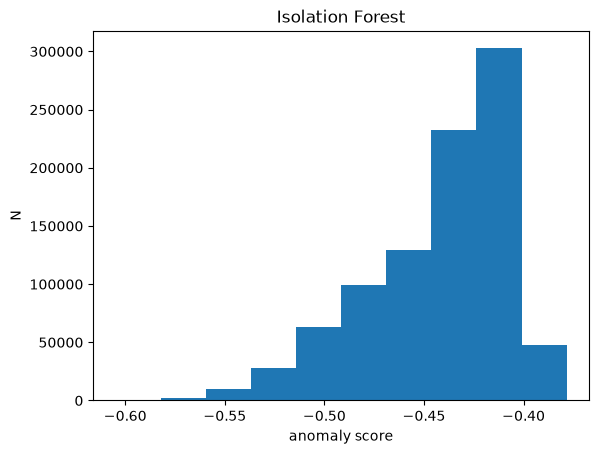

In [50]:
plt.hist(scores)
plt.xlabel('anomaly score')
plt.ylabel('N')
plt.title('Isolation Forest')
plt.show()

In [51]:
indx = np.argsort(scores)

**Result**: all scanned objects (indx=0-10, 100, 500, -1, -10000) are flat

# PineForest

In [75]:
import numpy as np
from coniferest.pineforest import PineForest
from coniferest.session import Session
from coniferest.session.callback import (
    TerminateAfter, prompt_decision_callback, viewer_decision_callback
)
from coniferest.label import Label

In [66]:
metadata = data['koid'].values

In [109]:
known_labels_pine = {np.uint64(67996): Label.REGULAR,
 np.uint64(835059): Label.REGULAR,
 np.uint64(543183): Label.REGULAR,
 np.uint64(419802): Label.REGULAR,
 np.uint64(446174): Label.REGULAR,
 np.uint64(49050): Label.REGULAR,
 np.uint64(402838): Label.REGULAR,
 np.uint64(420268): Label.REGULAR,
 np.uint64(425339): Label.REGULAR,
 np.uint64(150459): Label.REGULAR,
 np.uint64(67996): Label.REGULAR,
 np.uint64(514979): Label.REGULAR,
 np.uint64(263656): Label.REGULAR,
 np.uint64(21028): Label.REGULAR,
 np.uint64(530791): Label.REGULAR,
 np.uint64(848583): Label.REGULAR,
 np.uint64(421438): Label.REGULAR,
 np.uint64(403095): Label.REGULAR,
 np.uint64(426190): Label.REGULAR,
 np.uint64(35886): Label.REGULAR,
 np.uint64(853658): Label.REGULAR,
 np.uint64(208379): Label.REGULAR,
 np.uint64(444451): Label.REGULAR,
 np.uint64(667611): Label.REGULAR,
 np.uint64(706): Label.REGULAR,
 np.uint64(810765): Label.REGULAR,
 np.uint64(896420): Label.REGULAR,
 np.uint64(255263): Label.REGULAR,
 np.uint64(248686): Label.REGULAR,
 np.uint64(154004): Label.REGULAR,
 np.uint64(382225): Label.REGULAR,
 np.uint64(462880): Label.REGULAR,
 np.uint64(424358): Label.REGULAR,
 np.uint64(749955): Label.REGULAR,
 np.uint64(892018): Label.REGULAR,
 np.uint64(47226): Label.REGULAR,
 np.uint64(315181): Label.REGULAR,
 np.uint64(158373): Label.REGULAR,
 np.uint64(279080): Label.REGULAR,
 np.uint64(1325): Label.REGULAR,
 np.uint64(419889): Label.REGULAR,
 np.uint64(257333): Label.REGULAR,
 np.uint64(712804): Label.REGULAR,
 np.uint64(348737): Label.REGULAR,
 np.uint64(827412): Label.REGULAR,
 np.uint64(453873): Label.REGULAR,
 np.uint64(79245): Label.REGULAR,
 np.uint64(883552): Label.REGULAR,
 np.uint64(750065): Label.REGULAR,
 np.uint64(640824): Label.REGULAR,
 np.uint64(617437): Label.REGULAR,
np.uint64(877072): Label.REGULAR,
 np.uint64(564604): Label.REGULAR,
 np.uint64(208226): Label.REGULAR,
 np.uint64(437026): Label.REGULAR,
 np.uint64(217220): Label.REGULAR,
 np.uint64(213165): Label.REGULAR,
 np.uint64(543330): Label.REGULAR,
 np.uint64(880581): Label.REGULAR,
 np.uint64(839633): Label.REGULAR,
 np.uint64(828149): Label.REGULAR,
 np.uint64(871962): Label.REGULAR,
 np.uint64(499751): Label.REGULAR,
 np.uint64(705787): Label.REGULAR,
 np.uint64(131): Label.REGULAR,
 np.uint64(637177): Label.REGULAR,
 np.uint64(249474): Label.REGULAR,
 np.uint64(419961): Label.REGULAR,
 np.uint64(420209): Label.REGULAR,
 np.uint64(403294): Label.REGULAR,
 np.uint64(530204): Label.REGULAR,
np.uint64(308701): Label.REGULAR,
 np.uint64(216473): Label.REGULAR,
 np.uint64(197998): Label.REGULAR,
 np.uint64(381276): Label.REGULAR,
 np.uint64(117321): Label.REGULAR,
 np.uint64(5465): Label.REGULAR,
 np.uint64(425684): Label.REGULAR,
 np.uint64(828055): Label.REGULAR,
 np.uint64(543220): Label.REGULAR,
 np.uint64(338671): Label.REGULAR,
np.uint64(319174): Label.REGULAR,
 np.uint64(403170): Label.REGULAR,
 np.uint64(548252): Label.REGULAR,
 np.uint64(593777): Label.REGULAR,
 np.uint64(207990): Label.REGULAR,
 np.uint64(48544): Label.REGULAR,
 np.uint64(631458): Label.REGULAR,
 np.uint64(825394): Label.REGULAR,
 np.uint64(43443): Label.REGULAR,
 np.uint64(668): Label.REGULAR,
np.uint64(783497): Label.REGULAR,
 np.uint64(433929): Label.REGULAR,
 np.uint64(209513): Label.REGULAR,
 np.uint64(315031): Label.REGULAR,
 np.uint64(739275): Label.REGULAR,
 np.uint64(47121): Label.REGULAR,
 np.uint64(424354): Label.REGULAR,
 np.uint64(128997): Label.REGULAR,
 np.uint64(425815): Label.REGULAR,
 np.uint64(770569): Label.REGULAR,
 np.uint64(783497): Label.REGULAR,
 np.uint64(433929): Label.REGULAR,
 np.uint64(209513): Label.REGULAR,
 np.uint64(315031): Label.REGULAR,
 np.uint64(739275): Label.REGULAR,
 np.uint64(47121): Label.REGULAR,
 np.uint64(424354): Label.REGULAR,
 np.uint64(128997): Label.REGULAR,
 np.uint64(425815): Label.REGULAR,
 np.uint64(770569): Label.REGULAR}

In [ ]:
session = Session(
    data=data_input,
    metadata=metadata,
    known_labels=known_labels,
    model=PineForest(random_seed=0),
    decision_callback=viewer_decision_callback,
    on_decision_callbacks=TerminateAfter(10),
)
session.run()

In [112]:
len(known_labels)

100

In [121]:
session_pine_1k = Session(
    data=data_input,
    metadata=metadata,
    known_labels=known_labels,
    model=PineForest(random_seed=42, n_trees=1000),
    decision_callback=viewer_decision_callback,
    on_decision_callbacks=TerminateAfter(100),
)
session_pine_1k.run()

Check https://ztf.snad.space/view/718105400003356 for details


Is 718105400003356 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/759103200003932 for details


Is 759103200003932 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/626109100007220 for details


...

Is 848109100008984 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/848113300006177 for details


Is 848113300006177 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/848104100001804 for details


Is 848104100001804 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


In [122]:
# begin example
session_pine_1k.known_labels

{np.uint64(307056): <Label.REGULAR: 1>,
 np.uint64(2201): <Label.REGULAR: 1>,
 np.uint64(59501): <Label.REGULAR: 1>,
 np.uint64(637437): <Label.REGULAR: 1>,
 np.uint64(209490): <Label.REGULAR: 1>,
 np.uint64(774347): <Label.REGULAR: 1>,
 np.uint64(621448): <Label.REGULAR: 1>,
 np.uint64(777716): <Label.REGULAR: 1>,
 np.uint64(766592): <Label.REGULAR: 1>,
 np.uint64(209725): <Label.REGULAR: 1>,
 np.uint64(706280): <Label.REGULAR: 1>,
 np.uint64(187147): <Label.REGULAR: 1>,
 np.uint64(762105): <Label.REGULAR: 1>,
 np.uint64(773245): <Label.REGULAR: 1>,
 np.uint64(802140): <Label.REGULAR: 1>,
 np.uint64(36): <Label.REGULAR: 1>,
 np.uint64(893254): <Label.REGULAR: 1>,
 np.uint64(303912): <Label.REGULAR: 1>,
 np.uint64(907084): <Label.REGULAR: 1>,
 np.uint64(156980): <Label.REGULAR: 1>,
 np.uint64(209657): <Label.REGULAR: 1>,
 np.uint64(535724): <Label.REGULAR: 1>,
 np.uint64(389571): <Label.REGULAR: 1>,
 np.uint64(593126): <Label.REGULAR: 1>,
 np.uint64(853653): <Label.REGULAR: 1>,
 np.uin

In [ ]:
{np.uint64(307056): Label.REGULAR,
 np.uint64(2201): Label.REGULAR,
 np.uint64(59501): Label.REGULAR,
 np.uint64(637437): Label.REGULAR,
 np.uint64(209490): Label.REGULAR,
 np.uint64(774347): Label.REGULAR,
 np.uint64(621448): Label.REGULAR,
 np.uint64(777716): Label.REGULAR,
 np.uint64(766592): Label.REGULAR,
 np.uint64(209725): Label.REGULAR,
 np.uint64(706280): Label.REGULAR,
 np.uint64(187147): Label.REGULAR,
 np.uint64(762105): Label.REGULAR,
 np.uint64(773245): Label.REGULAR,
 np.uint64(802140): Label.REGULAR,
 np.uint64(36): Label.REGULAR,
 np.uint64(893254): Label.REGULAR,
 np.uint64(303912): Label.REGULAR,
 np.uint64(907084): Label.REGULAR,
 np.uint64(156980): Label.REGULAR,
 np.uint64(209657): Label.REGULAR,
 np.uint64(535724): Label.REGULAR,
 np.uint64(389571): Label.REGULAR,
 np.uint64(593126): Label.REGULAR,
 np.uint64(853653): Label.REGULAR,
 np.uint64(369): Label.REGULAR,
 np.uint64(542671): Label.REGULAR,
 np.uint64(454059): Label.REGULAR,
 np.uint64(571819): Label.REGULAR,
 np.uint64(308545): Label.REGULAR,
 np.uint64(147698): Label.REGULAR,
 np.uint64(763250): Label.REGULAR,
 np.uint64(5681): Label.REGULAR,
 np.uint64(871169): Label.REGULAR,
 np.uint64(403198): Label.REGULAR,
 np.uint64(237456): Label.REGULAR,
 np.uint64(614018): Label.REGULAR,
 np.uint64(837123): Label.REGULAR,
 np.uint64(68391): Label.REGULAR,
 np.uint64(13874): Label.REGULAR,
 np.uint64(172240): Label.REGULAR,
 np.uint64(913857): Label.REGULAR,
 np.uint64(47675): Label.REGULAR,
 np.uint64(58528): Label.REGULAR,
 np.uint64(708): Label.REGULAR,
 np.uint64(835059): Label.REGULAR,
 np.uint64(868653): Label.REGULAR,
 np.uint64(566930): Label.REGULAR,
 np.uint64(828037): Label.REGULAR,
 np.uint64(375715): Label.REGULAR,
 np.uint64(776221): Label.REGULAR,
 np.uint64(632566): Label.REGULAR,
 np.uint64(118818): Label.REGULAR,
 np.uint64(641116): Label.REGULAR,
 np.uint64(218450): Label.REGULAR,
 np.uint64(451645): Label.REGULAR,
 np.uint64(635664): Label.REGULAR,
 np.uint64(122077): Label.REGULAR,
 np.uint64(24656): Label.REGULAR,
 np.uint64(314799): Label.REGULAR,
 np.uint64(759232): Label.REGULAR,
 np.uint64(734065): Label.REGULAR,
 np.uint64(627649): Label.REGULAR,
 np.uint64(677852): Label.REGULAR,
 np.uint64(848511): Label.REGULAR,
 np.uint64(244885): Label.REGULAR,
 np.uint64(314713): Label.REGULAR,
 np.uint64(340437): Label.REGULAR,
 np.uint64(140921): Label.REGULAR,
 np.uint64(83559): Label.REGULAR,
 np.uint64(660956): Label.REGULAR,
 np.uint64(747547): Label.REGULAR,
 np.uint64(644811): Label.REGULAR,
 np.uint64(351375): Label.REGULAR,
 np.uint64(272569): Label.REGULAR,
 np.uint64(153925): Label.REGULAR,
 np.uint64(423336): Label.REGULAR,
 np.uint64(425640): Label.REGULAR,
 np.uint64(299571): Label.REGULAR,
 np.uint64(976): Label.REGULAR,
 np.uint64(265837): Label.REGULAR,
 np.uint64(616661): Label.REGULAR,
 np.uint64(759508): Label.REGULAR,
 np.uint64(219495): Label.REGULAR,
 np.uint64(238769): Label.REGULAR,
 np.uint64(419882): Label.REGULAR,
 np.uint64(896007): Label.REGULAR,
 np.uint64(314792): Label.REGULAR,
 np.uint64(510713): Label.REGULAR,
 np.uint64(180329): Label.REGULAR,
 np.uint64(739187): Label.REGULAR,
 np.uint64(209477): Label.REGULAR,
 np.uint64(602983): Label.REGULAR,
 np.uint64(420099): Label.REGULAR,
 np.uint64(452219): Label.REGULAR,
 np.uint64(776171): Label.REGULAR,
 np.uint64(533363): Label.REGULAR,
 np.uint64(630586): Label.REGULAR,
 np.uint64(613005): Label.REGULAR,
 np.uint64(453467): Label.REGULAR,
 np.uint64(67996): Label.REGULAR,
 np.uint64(175918): Label.REGULAR,
 np.uint64(98698): Label.REGULAR,
 np.uint64(736147): Label.REGULAR,
 np.uint64(406): Label.REGULAR,
 np.uint64(739213): Label.REGULAR,
 np.uint64(530417): Label.REGULAR,
 np.uint64(174257): Label.REGULAR,
 np.uint64(811917): Label.REGULAR,
 np.uint64(706): Label.REGULAR,
 np.uint64(174258): Label.REGULAR,
 np.uint64(174177): Label.REGULAR,
 np.uint64(308701): Label.REGULAR,
 np.uint64(668): Label.REGULAR,
 np.uint64(126429): Label.REGULAR,
 np.uint64(423605): Label.REGULAR,
 np.uint64(131): Label.REGULAR,
 np.uint64(255634): Label.REGULAR,
 np.uint64(158373): Label.REGULAR,
 np.uint64(174354): Label.REGULAR,
 np.uint64(558144): Label.REGULAR,
 np.uint64(802227): Label.REGULAR,
 np.uint64(240014): Label.REGULAR,
 np.uint64(842422): Label.REGULAR,
 np.uint64(434556): Label.REGULAR,
 np.uint64(828035): Label.REGULAR,
 np.uint64(122985): Label.REGULAR,
 np.uint64(120884): Label.REGULAR,
 np.uint64(741670): Label.REGULAR,
 np.uint64(840168): Label.REGULAR,
 np.uint64(492723): Label.REGULAR,
 np.uint64(98175): Label.REGULAR,
 np.uint64(425320): Label.REGULAR,
 np.uint64(314935): Label.REGULAR,
 np.uint64(120881): Label.REGULAR,
 np.uint64(45151): Label.REGULAR,
 np.uint64(892018): Label.REGULAR,
 np.uint64(739275): Label.REGULAR,
 np.uint64(208533): Label.REGULAR,
 np.uint64(677700): Label.REGULAR,
 np.uint64(258842): Label.REGULAR,
 np.uint64(802108): Label.REGULAR,
 np.uint64(543232): Label.REGULAR,
 np.uint64(832469): Label.REGULAR,
 np.uint64(694687): Label.REGULAR,
 np.uint64(468803): Label.REGULAR,
 np.uint64(543216): Label.REGULAR,
 np.uint64(315019): Label.REGULAR,
 np.uint64(208579): Label.REGULAR,
 np.uint64(626907): Label.REGULAR,
 np.uint64(174180): Label.REGULAR,
 np.uint64(46028): Label.REGULAR,
 np.uint64(499751): Label.REGULAR,
 np.uint64(669): Label.REGULAR,
 np.uint64(330588): Label.REGULAR,
 np.uint64(147515): Label.REGULAR,
 np.uint64(368239): Label.REGULAR,
 np.uint64(425840): Label.REGULAR,
 np.uint64(403146): Label.REGULAR,
 np.uint64(286596): Label.REGULAR,
 np.uint64(660952): Label.REGULAR,
 np.uint64(659622): Label.REGULAR,
 np.uint64(530133): Label.REGULAR,
 np.uint64(756352): Label.REGULAR,
 np.uint64(277682): Label.REGULAR,
 np.uint64(224809): Label.REGULAR,
 np.uint64(435576): Label.REGULAR,
 np.uint64(314752): Label.REGULAR,
 np.uint64(559114): Label.REGULAR,
 np.uint64(437026): Label.REGULAR,
 np.uint64(530791): Label.REGULAR,
 np.uint64(403265): Label.REGULAR,
 np.uint64(802467): Label.REGULAR,
 np.uint64(672052): Label.REGULAR,
 np.uint64(49050): Label.REGULAR,
 np.uint64(140712): Label.REGULAR,
 np.uint64(834965): Label.REGULAR,
 np.uint64(257217): Label.REGULAR,
 np.uint64(423733): Label.REGULAR,
 np.uint64(154004): Label.REGULAR,
 np.uint64(801904): Label.REGULAR,
 np.uint64(46726): Label.REGULAR,
 np.uint64(208249): Label.REGULAR,
 np.uint64(532358): Label.REGULAR,
 np.uint64(707767): Label.REGULAR,
 np.uint64(35886): Label.REGULAR,
 np.uint64(209676): Label.REGULAR,
 np.uint64(710118): Label.REGULAR,
 np.uint64(267125): Label.REGULAR,
 np.uint64(315044): Label.REGULAR,
 np.uint64(216473): Label.REGULAR,
 np.uint64(188972): Label.REGULAR,
 np.uint64(530723): Label.REGULAR,
 np.uint64(802402): Label.REGULAR,
 np.uint64(781024): Label.REGULAR,
 np.uint64(427070): Label.REGULAR,
 np.uint64(446544): Label.REGULAR,
 np.uint64(510021): Label.REGULAR,
 np.uint64(834978): Label.REGULAR,
 np.uint64(685148): Label.REGULAR}

# AAD

In [114]:
from coniferest.aadforest import AADForest

In [116]:
session_aad = Session(
    data=data_input,
    metadata=metadata,
    model=AADForest(random_seed=42),
    decision_callback=viewer_decision_callback,
    on_decision_callbacks=TerminateAfter(100),
)
session_aad.run()

Check https://ztf.snad.space/view/759105200002614 for details


Is 759105200002614 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/797112400008894 for details


Is 797112400008894 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/848107400004523 for details


...

Is 797109400003017 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/797106100001562 for details


Is 797106100001562 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


Check https://ztf.snad.space/view/795105200000022 for details


Is 795105200000022 an anomaly? ([A]nomaly / yes, [R]egular / no, [U]nknown):  n


In [ ]:
session_aad.known_labels

In [118]:
known_labels_aad = {np.uint64(307056): Label.REGULAR,
 np.uint64(2201): Label.REGULAR,
 np.uint64(59501): Label.REGULAR,
 np.uint64(637437): Label.REGULAR,
 np.uint64(209490): Label.REGULAR,
 np.uint64(774347): Label.REGULAR,
 np.uint64(621448): Label.REGULAR,
 np.uint64(777716): Label.REGULAR,
 np.uint64(766592): Label.REGULAR,
 np.uint64(209725): Label.REGULAR,
 np.uint64(706280): Label.REGULAR,
 np.uint64(187147): Label.REGULAR,
 np.uint64(762105): Label.REGULAR,
 np.uint64(773245): Label.REGULAR,
 np.uint64(802140): Label.REGULAR,
 np.uint64(36): Label.REGULAR,
 np.uint64(893254): Label.REGULAR,
 np.uint64(303912): Label.REGULAR,
 np.uint64(907084): Label.REGULAR,
 np.uint64(156980): Label.REGULAR,
 np.uint64(209657): Label.REGULAR,
 np.uint64(535724): Label.REGULAR,
 np.uint64(389571): Label.REGULAR,
 np.uint64(593126): Label.REGULAR,
 np.uint64(853653): Label.REGULAR,
 np.uint64(369): Label.REGULAR,
 np.uint64(542671): Label.REGULAR,
 np.uint64(454059): Label.REGULAR,
 np.uint64(571819): Label.REGULAR,
 np.uint64(308545): Label.REGULAR,
 np.uint64(147698): Label.REGULAR,
 np.uint64(763250): Label.REGULAR,
 np.uint64(5681): Label.REGULAR,
 np.uint64(871169): Label.REGULAR,
 np.uint64(403198): Label.REGULAR,
 np.uint64(237456): Label.REGULAR,
 np.uint64(614018): Label.REGULAR,
 np.uint64(837123): Label.REGULAR,
 np.uint64(68391): Label.REGULAR,
 np.uint64(13874): Label.REGULAR,
 np.uint64(172240): Label.REGULAR,
 np.uint64(913857): Label.REGULAR,
 np.uint64(47675): Label.REGULAR,
 np.uint64(58528): Label.REGULAR,
 np.uint64(708): Label.REGULAR,
 np.uint64(835059): Label.REGULAR,
 np.uint64(868653): Label.REGULAR,
 np.uint64(566930): Label.REGULAR,
 np.uint64(828037): Label.REGULAR,
 np.uint64(375715): Label.REGULAR,
 np.uint64(776221): Label.REGULAR,
 np.uint64(632566): Label.REGULAR,
 np.uint64(118818): Label.REGULAR,
 np.uint64(641116): Label.REGULAR,
 np.uint64(218450): Label.REGULAR,
 np.uint64(451645): Label.REGULAR,
 np.uint64(635664): Label.REGULAR,
 np.uint64(122077): Label.REGULAR,
 np.uint64(24656): Label.REGULAR,
 np.uint64(314799): Label.REGULAR,
 np.uint64(759232): Label.REGULAR,
 np.uint64(734065): Label.REGULAR,
 np.uint64(627649): Label.REGULAR,
 np.uint64(677852): Label.REGULAR,
 np.uint64(848511): Label.REGULAR,
 np.uint64(244885): Label.REGULAR,
 np.uint64(314713): Label.REGULAR,
 np.uint64(340437): Label.REGULAR,
 np.uint64(140921): Label.REGULAR,
 np.uint64(83559): Label.REGULAR,
 np.uint64(660956): Label.REGULAR,
 np.uint64(747547): Label.REGULAR,
 np.uint64(644811): Label.REGULAR,
 np.uint64(351375): Label.REGULAR,
 np.uint64(272569): Label.REGULAR,
 np.uint64(153925): Label.REGULAR,
 np.uint64(423336): Label.REGULAR,
 np.uint64(425640): Label.REGULAR,
 np.uint64(299571): Label.REGULAR,
 np.uint64(976): Label.REGULAR,
 np.uint64(265837): Label.REGULAR,
 np.uint64(616661): Label.REGULAR,
 np.uint64(759508): Label.REGULAR,
 np.uint64(219495): Label.REGULAR,
 np.uint64(238769): Label.REGULAR,
 np.uint64(419882): Label.REGULAR,
 np.uint64(896007): Label.REGULAR,
 np.uint64(314792): Label.REGULAR,
 np.uint64(510713): Label.REGULAR,
 np.uint64(180329): Label.REGULAR,
 np.uint64(739187): Label.REGULAR,
 np.uint64(209477): Label.REGULAR,
 np.uint64(602983): Label.REGULAR,
 np.uint64(420099): Label.REGULAR,
 np.uint64(452219): Label.REGULAR,
 np.uint64(776171): Label.REGULAR,
 np.uint64(533363): Label.REGULAR,
 np.uint64(630586): Label.REGULAR,
 np.uint64(613005): Label.REGULAR,
 np.uint64(453467): Label.REGULAR}